# Atelier Seaborn Contexte
 Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

# 
2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
3) Créer le notebook atelier_seaborn_iot.ipynb 
4) Installer et importer seaborn, matplotlib, pandas, numpy 
5) Importer mesures_capteurs.csv dans le dataframe df 
6) Vérifier le contenu du dataframe df 

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")


In [102]:
sns.__version__

'0.13.2'

In [103]:
# 5) Importer mesures_capteurs.csv dans le dataframe df 
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [104]:
df.shape

(605, 9)

In [105]:
df.ndim

2

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


# Partie 1 – Distribution d'une variable avec histplot()
 1) Afficher la distribution des températures 
 2) Autour de quelle valeur les températures sont concentrées ? 
 3) La distribution semble-t-elle symétrique ? 
 4) Existe-t-il des valeurs extrêmes ? 
 5) Modifier le nombre de classes 
 6) Afficher la distribution des températures par bâtiment

##  1) Afficher la distribution des températures 

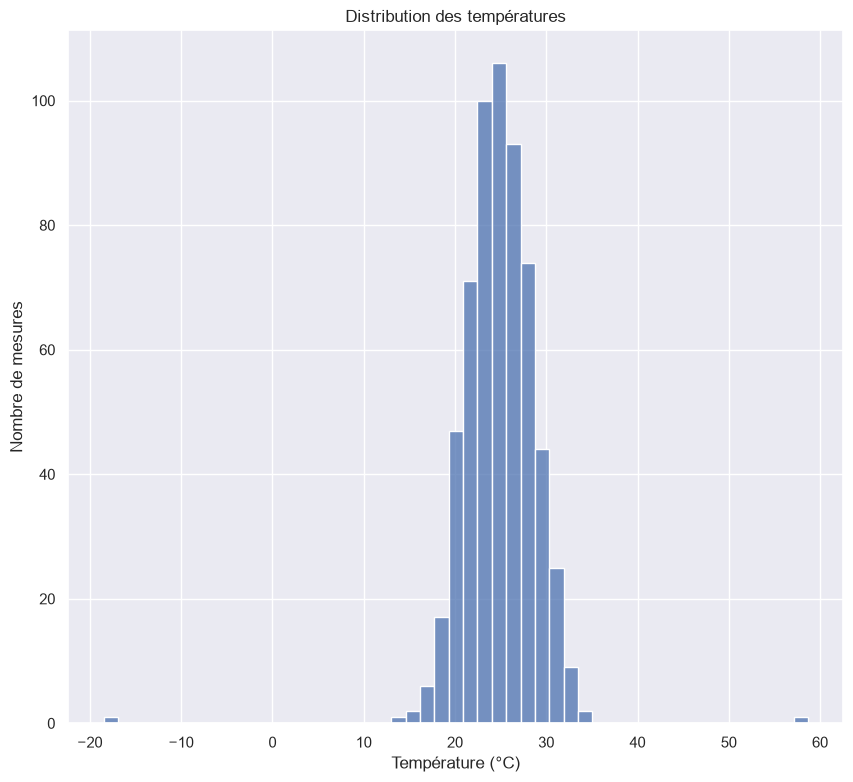

In [107]:
plt.figure(figsize=(10, 9))

sns.histplot(data=df, x="temperature" )
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

##  2) Autour de quelle valeur les températures sont concentrées ? 
 Les températures se concentrent autour de ~25°C, là où le pic de l'histogramme (et de la 
courbe KDE) est le plus haut

##  3) La distribution semble-t-elle symétrique ? 
 La distribution semble symétrique la courbe KDE dessine une forme de cloche assez 
régulière, montant puis redescendant de façon comparable de part et d'autre du pic.

##  4) Existe-t-il des valeurs extrêmes ? 
 Oui — on voit deux petites barres quasi invisibles, isolées loin du pic principal : une vers 
-20°C, une vers 58°C. Un grand espace vide les sépare du reste de la distribution.

## 5) Modifier le nombre de classes 

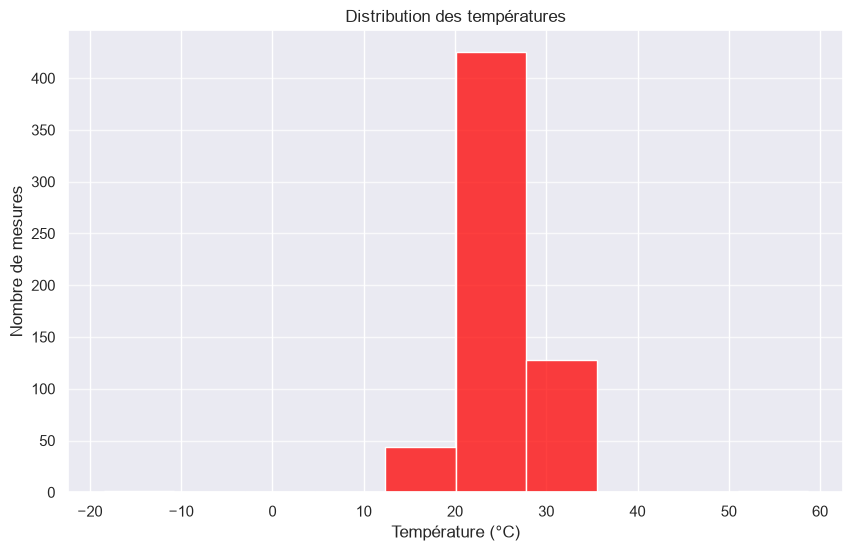

In [108]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="temperature" , bins=10, color="red")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis='y', alpha=0.75)
plt.show()



Avec 10 classes, on ne distingue plus clairement que 3 grandes barres (autour de 15-20°C, 
20-28°C, et 28-35°C) — les valeurs aberrantes autour de -18.5°C et 58.7°C, bien que 
techniquement présentes, sont écrasées à la fois par leur position isolée et par leur 
hauteur minuscule comparée au pic central. Avec 20 ou 30 classes (vu précédemment), ces 
valeurs isolées restent tout aussi invisibles, pour la même raison. Réduire le nombre de 
classes rend la forme générale plus lisse mais fait perdre en détail sur la répartition 
précise des mesures centrales.

## 6) Afficher la distribution des températures par bâtiment


Text(0, 0.5, 'Nombre de mesures')

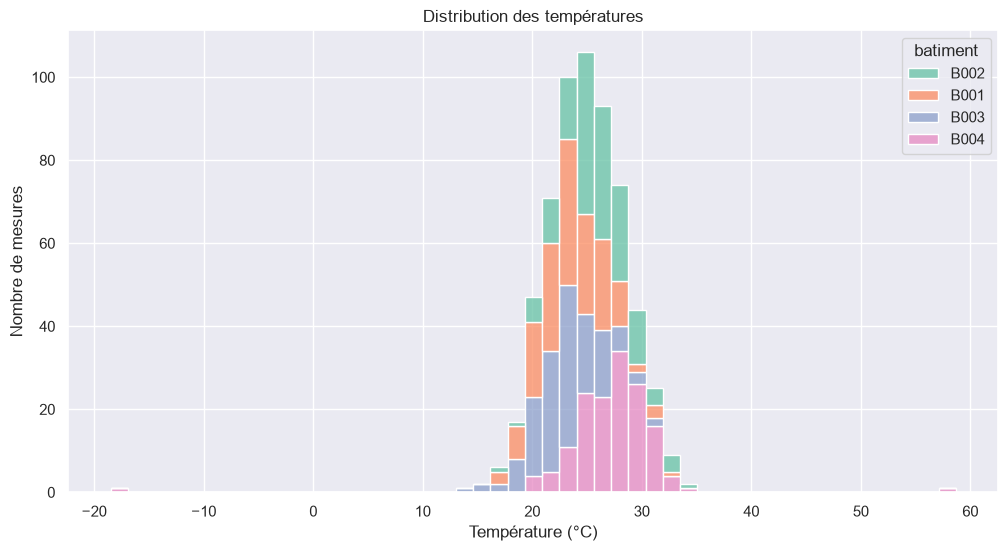

In [109]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x="temperature" ,hue="batiment", multiple="stack", palette="Set2")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")




Les 4 bâtiments montrent des distributions globalement similaires et superposées autour du 
pic central (20-30°C) — pas de différence marquante dans leur comportement normal. En 
revanche, les deux valeurs extrêmes déjà identifiées (vers -18°C et 58°C) sont toutes les 
deux colorées en rose, donc appartiennent au même bâtiment : B004. Cela confirme l'hypothèse 
déjà formulée dans l'atelier Matplotlib — B004 semble avoir un capteur ou un système 
présentant un dysfonctionnement récurrent, distinct des trois autres bâtiments.

# Partie 2 – Distribution d'une variable avec kdeplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 

## 1) Afficher la distribution des températures 


Text(0, 0.5, 'Densité')

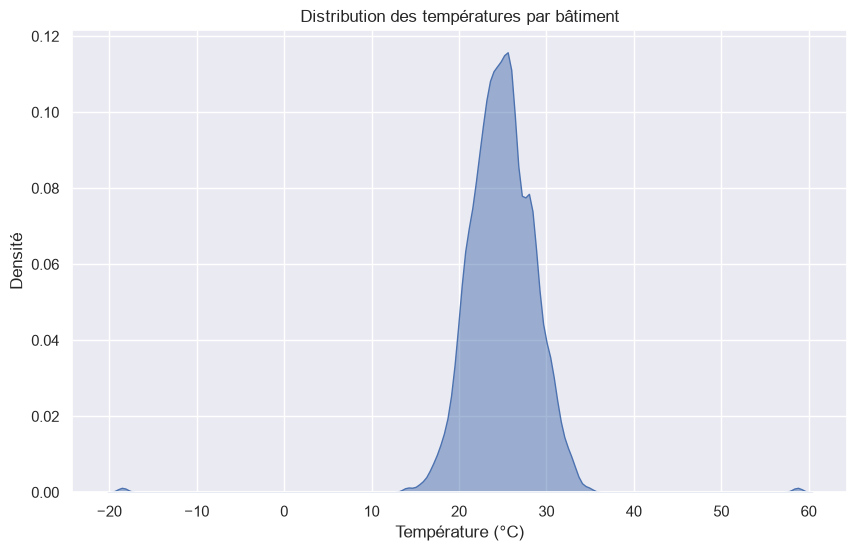

In [110]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature", fill=True, alpha=0.5, bw_adjust=0.5)  
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")

## 2) Afficher la distribution des températures par bâtiment 

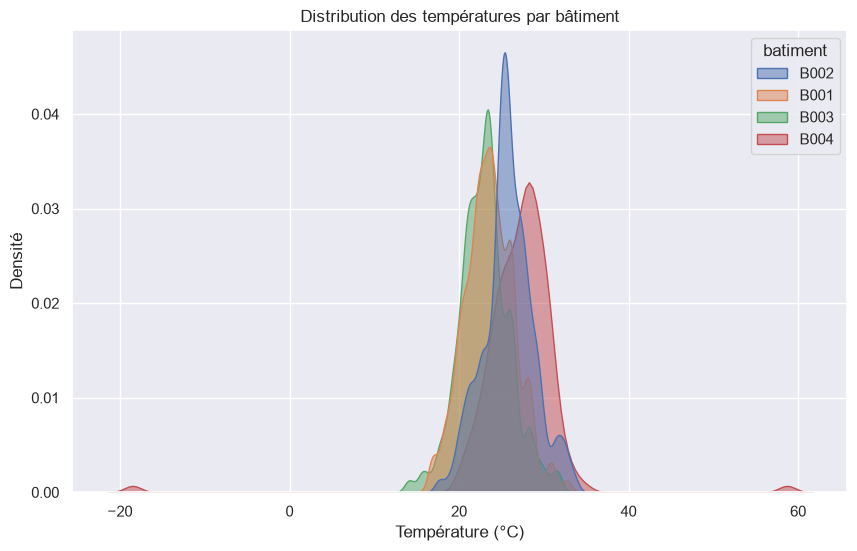

In [111]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.5, bw_adjust=0.5)
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

## Interprétation - Distribution des températures par bâtiment (KDE)

Les 4 bâtiments partagent une tendance générale similaire, avec un pic principal 
concentré entre 20°C et 30°C. B002 présente le pic le plus net et le plus élevé (autour 
de 26°C), signe d'une température très stable pour ce bâtiment. À l'inverse, B004 
montre une courbe plus étalée et moins haute, signe d'une plus grande variabilité de 
température - cohérent avec le fait que ce même bâtiment concentre déjà les valeurs 
aberrantes identifiées précédemment (pic à ~58°C, creux à ~-20°C, visibles ici comme 
de petites bosses isolées aux extrémités).

# Partie 3 – Distribution d'une variable avec boxplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 
3) Pour chaque bâtiment, 
 a) quelle est la médiane ?  
 b) quelle est la dispersion ?  
 c) les valeurs extrêmes 
4) quels bâtiments ont les valeurs les plus extrêmes ?  

## 1) Afficher la distribution des températures 


Text(0, 0.5, 'Nombre de mesures')

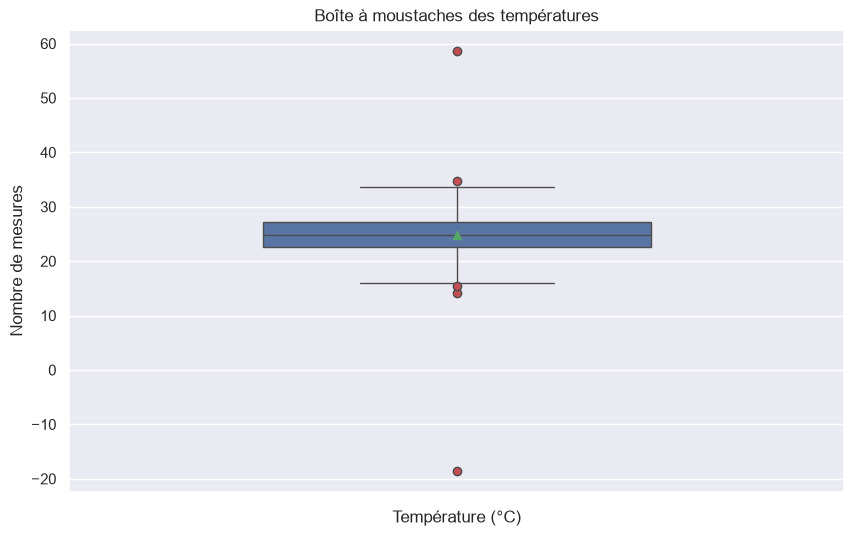

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y="temperature",width=0.5, showmeans=True, flierprops=dict(markerfacecolor='r', marker='o'))
plt.title("Boîte à moustaches des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")

## 2) Afficher la distribution des températures par bâtiment 


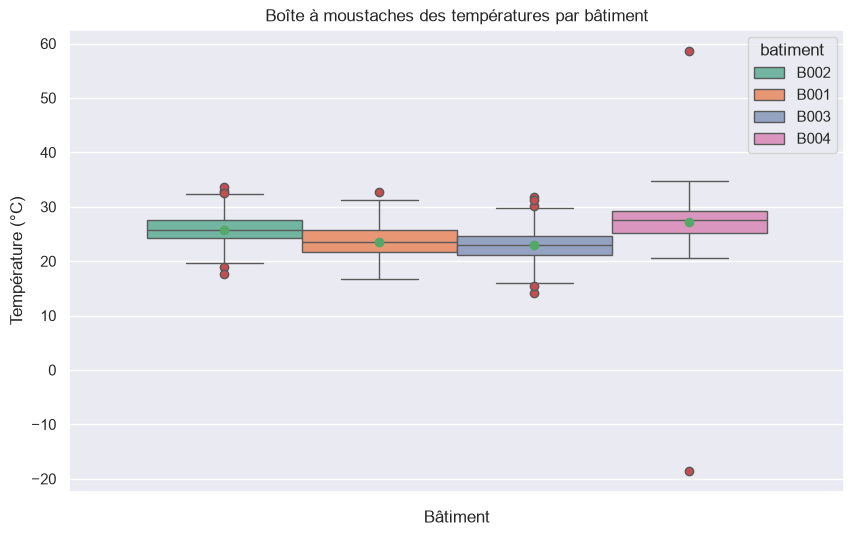

In [144]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y="temperature",hue="batiment", showmeans=True,meanprops=dict(marker='o', markerfacecolor='g'), flierprops=dict(markerfacecolor='r', marker='o'),palette="Set2")
plt.title("Boîte à moustaches des températures par bâtiment")   
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

## Question 3 : Pour chaque bâtiment

a) Médiane
- B002 : ~26°C
- B001 : ~23°C
- B003 : ~23°C
- B004 : ~28°C (la plus haute)

b) Dispersion
- B002, B001, B003 : boîtes et moustaches similaires, dispersion modérée
- B004 : boîte la plus large, la plus dispersée des 4

c) Valeurs extrêmes
- B002 : 4  valeures isolées proches des moustaches (haut et bas)
- B001 : un point isolé en haut
- B003 : 4  valeures isolées proches des moustaches (haut et bas)
- B004 : 2 valeurs très extrêmes (~58°C et ~-20°C), bien plus éloignées que les autres



## Question 4 : Quels bâtiments ont les valeurs les plus extrêmes ?

B004, nettement — ses deux valeurs aberrantes (~58°C et ~-20°C) sont bien plus éloignées 
de la boîte que tous les points isolés des 3 autres bâtiments.

# Partie 4 – Distribution d'une variable avec violinplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 
3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ? 

## 1) Afficher la distribution des températures 


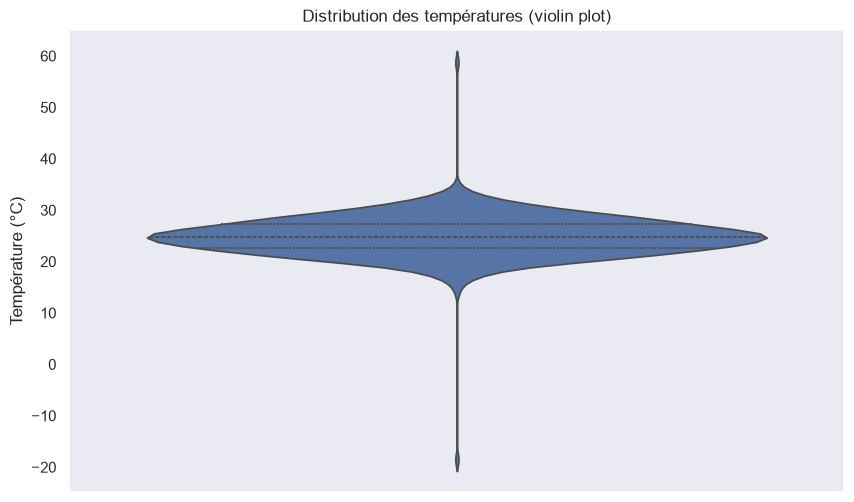

In [135]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, y="temperature", inner="quartile",saturation=0.8, )
plt.title("Distribution des températures (violin plot)")
plt.ylabel("Température (°C)")
plt.grid(axis="y")
plt.show()

## 2) Afficher la distribution des températures par bâtiment 


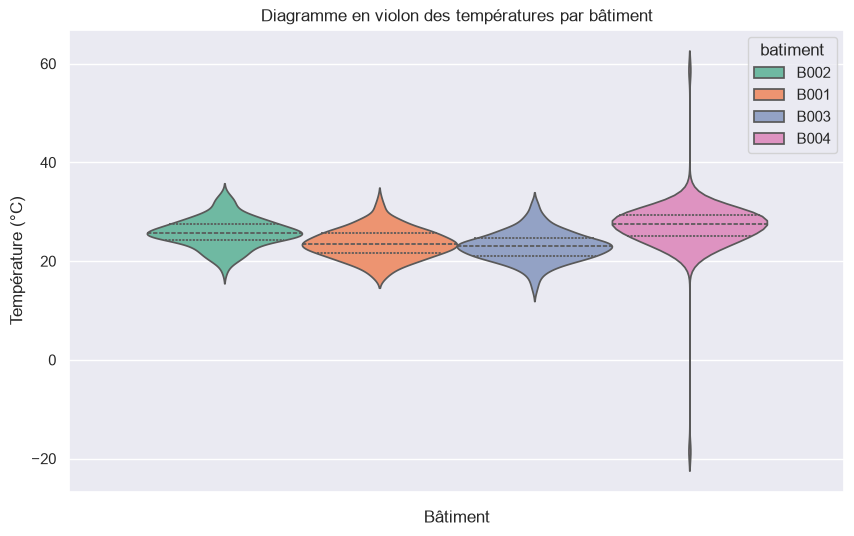

In [142]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, y="temperature", inner="quartile",hue="batiment", saturation=0.8, palette="Set2")
plt.title("Diagramme en violon des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

## 3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ? 


Le box plot résume la distribution en quelques chiffres (médiane, quartiles, moustaches, 
points aberrants), mais ne montre pas sa vraie forme. Le violin plot ajoute la silhouette 
complète de la distribution (comme un KDE) : on voit si les données se concentrent en un 
seul pic ou plusieurs (distribution bimodale), et où exactement la densité est la plus 
forte - des informations invisibles sur un simple box plot, qui pourrait sembler identique 
pour deux distributions de formes très différentes.

# Partie 5 – Comptage des catégories avec countplot() 
1) Afficher le nombre de mesures par état  
2) Afficher le nombre de mesures par bâtiment 
3) Afficher les états des capteurs par bâtiment pour identifier  
 a) le bâtiment ayant le plus de mesures en état OK ; 
 b) celui ayant le plus de mesures en ALERTE ; 
 c) celui ayant le plus de mesures en ERREUR. 

## 1) Afficher le nombre de mesures par état  


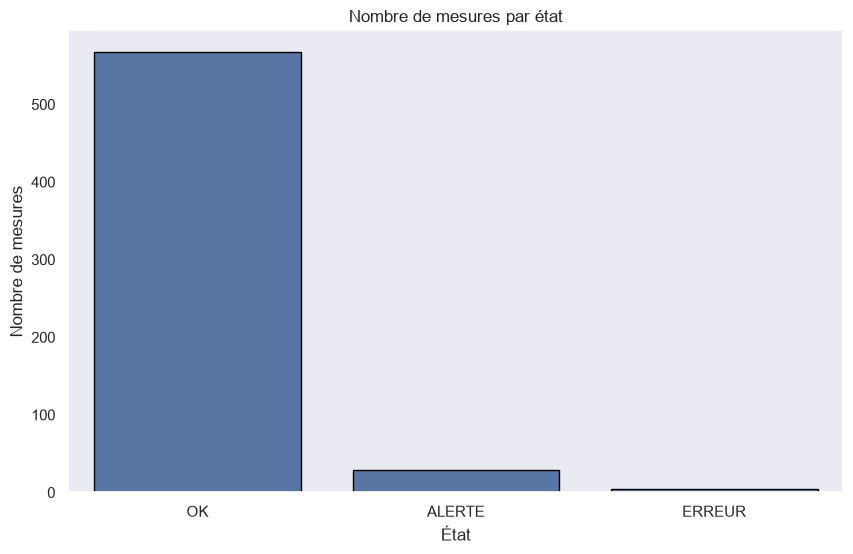

In [151]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="etat", edgecolor="black")
plt.title("Nombre de mesures par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

## 2) Afficher le nombre de mesures par bâtiment 


C:\Users\DELL\AppData\Local\Temp\ipykernel_27420\3532557555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="batiment", palette="Set2", edgecolor="black")


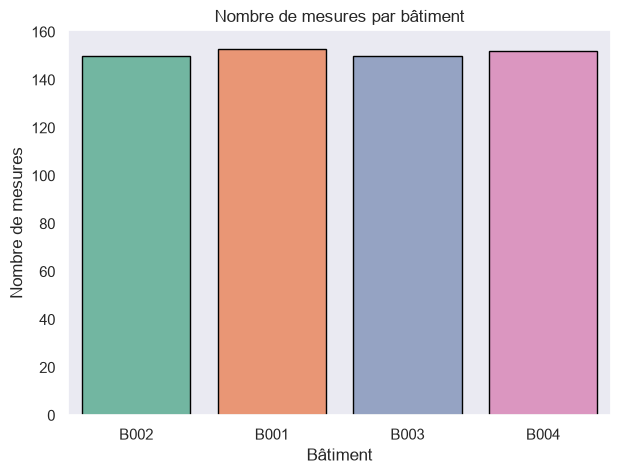

In [148]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="batiment", palette="Set2", edgecolor="black")
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

## 3) Afficher les états des capteurs par bâtiment pour identifier  


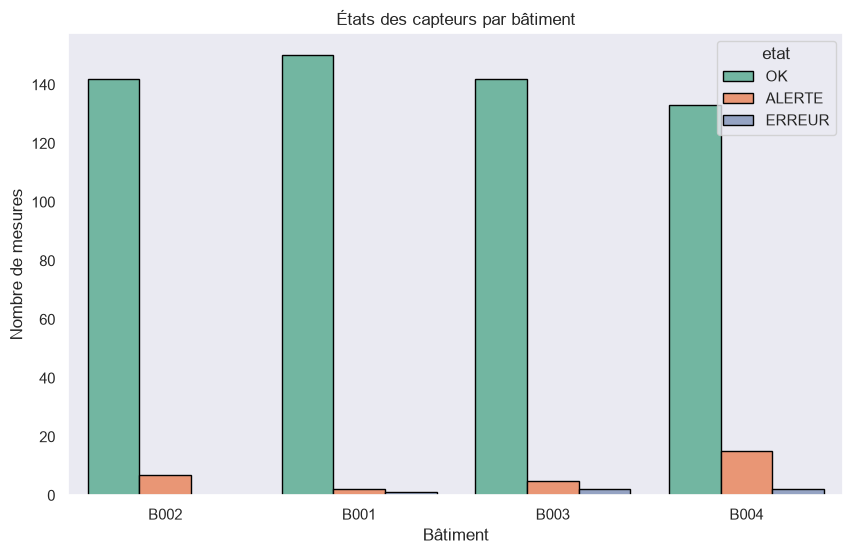

In [149]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="batiment", hue="etat", palette="Set2", edgecolor="black")
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

## 


a) Le plus de mesures en OK : B001 (barre verte la plus haute, ~150).

b) Le plus en ALERTE : B004, nettement (barre orange visiblement plus haute que les 
3 autres, ~20 contre 5-8 ailleurs).

c) Le plus en ERREUR : B003 et B004 semble etre en  égalité  

# Partie 6 – Relation entre deux variables avec scatterplot() 
1) Etudier graphiquement la relation entre température et consommation 
2) Etudier graphiquement la relation entre température et consommation par bâtiment 
3) Modifier la taille des points 

## 1) Etudier graphiquement la relation entre température et consommation 


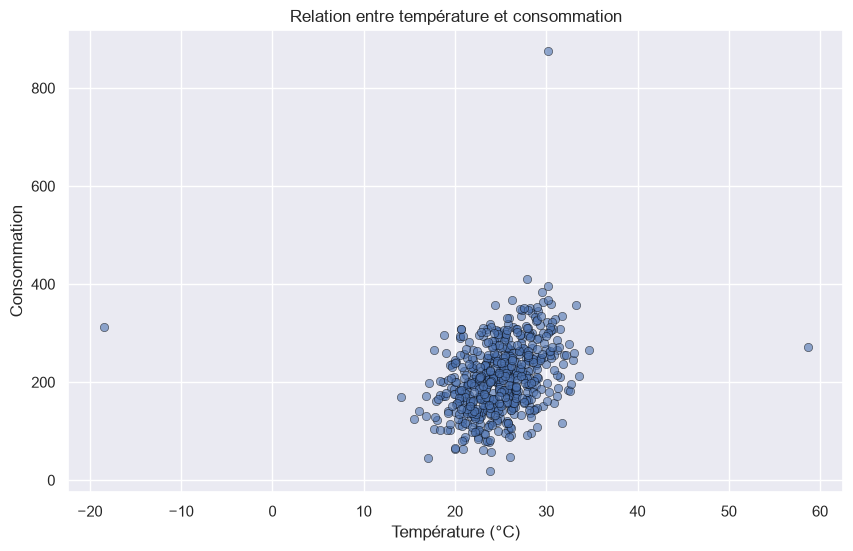

In [158]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", alpha=0.6, edgecolor="black")
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()



Le nuage de points forme un amas dense et arrondi, concentré entre 15-35°C et 100-400 
de consommation, sans direction diagonale nette. Aucune relation claire ne se dégage 
visuellement - la consommation ne semble pas dépendre directement de la température. 
On note aussi 3 points isolés, loin du nuage principal (vers -20°C, +58°C, et un point 
de consommation exceptionnellement élevée vers 870), qui correspondent aux anomalies 
déjà identifiées dans les parties précédentes.

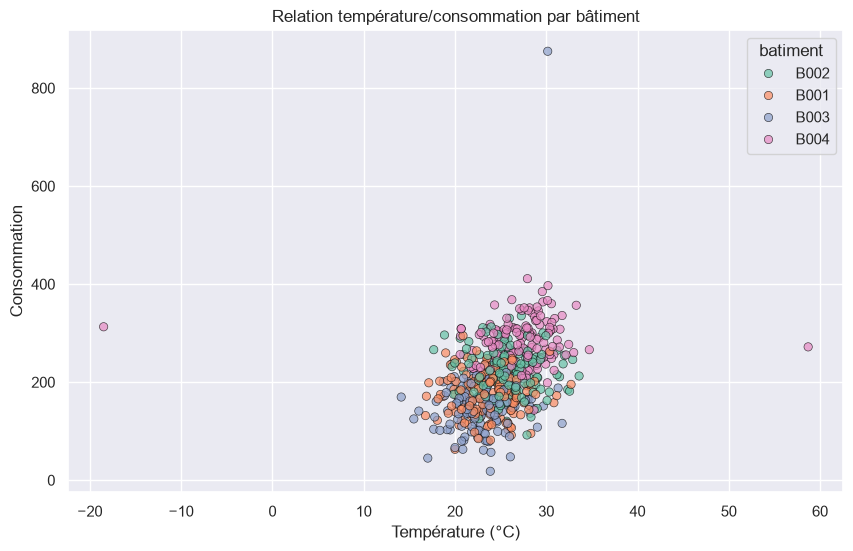

In [157]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", 
                 palette="Set2", alpha=0.7, edgecolor="black")
plt.title("Relation température/consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()

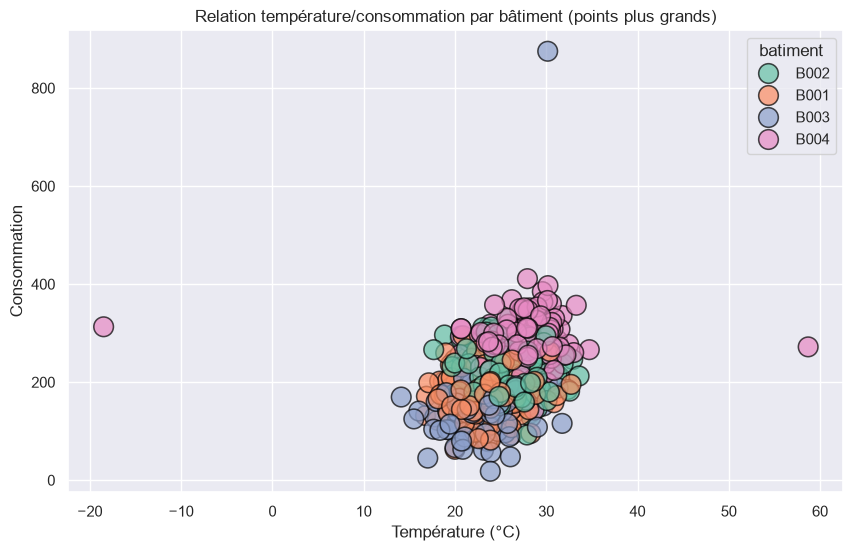

In [156]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", 
                 palette="Set2", s=200, alpha=0.7, edgecolor="black")
plt.title("Relation température/consommation par bâtiment (points plus grands)")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()

##  Étude par bâtiment

La coloration par bâtiment révèle une information invisible sur le graphique global : 
B004 (rose) occupe surtout la partie haute du nuage, avec une consommation généralement 
plus élevée que les autres bâtiments à température comparable - cohérent avec les 
observations précédentes (B004 avait déjà la consommation moyenne la plus élevée ). B003 (bleu-gris), à l'inverse, se situe plutôt dans la partie basse. Les 
deux anomalies de température (-20°C et 58°C) sont toutes deux roses (B004), confirmant 
une nouvelle fois l'origine de ces valeurs extrêmes. Le point de consommation 
exceptionnelle (~870) appartient cependant à B003, une anomalie distincte, indépendante 
du profil habituel de B004.

# Partie 7 – Régression avec regplot() 
Etudier graphiquement une tendance entre température et consommation 

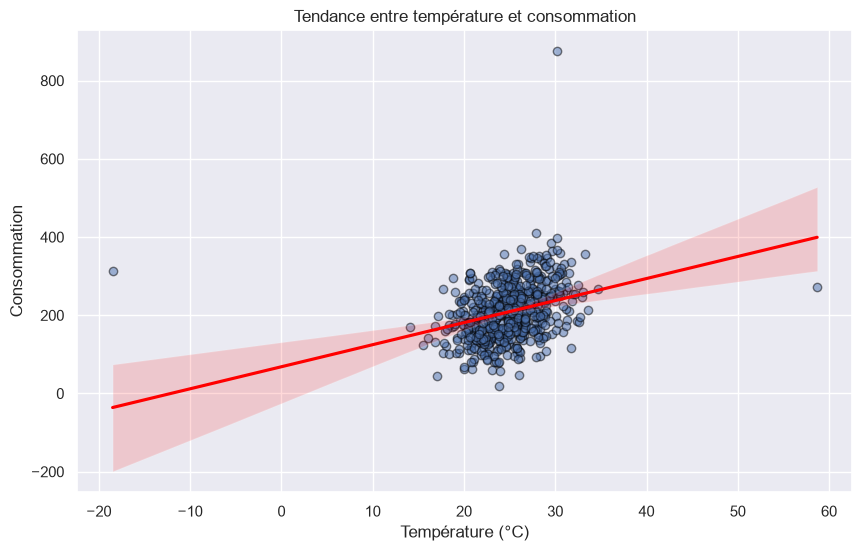

In [160]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="temperature", y="consommation", 
            scatter_kws={"alpha": 0.5, "edgecolor": "black"}, 
            line_kws={"color": "red"})
plt.title("Tendance entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()

## Interprétation - Régression température/consommation

La droite de régression monte de gauche à droite, indiquant que la consommation tend 
à augmenter avec la température. Cette tendance est fiable dans la zone centrale 
(20-30°C), où la bande de confiance reste étroite - beaucoup de mesures y sont 
concentrées, ce qui permet d'affirmer la tendance avec assez de certitude à ces 
températures. En revanche, aux extrémités (froid ou chaud extrême), la bande s'élargit 
fortement : on ne peut PAS conclure avec la même certitude que la relation se maintient 
à ces valeurs, faute de données suffisantes à ces plages de température. La relation 
observée entre température et consommation doit donc être comprise comme valable 
principalement pour les températures courantes du dataset, pas comme une règle générale 
extrapolable à n'importe quelle température.

# Partie 8 – Régression avec lmplot() 
Etudier graphiquement une tendance entre température et consommation par bâtiment  

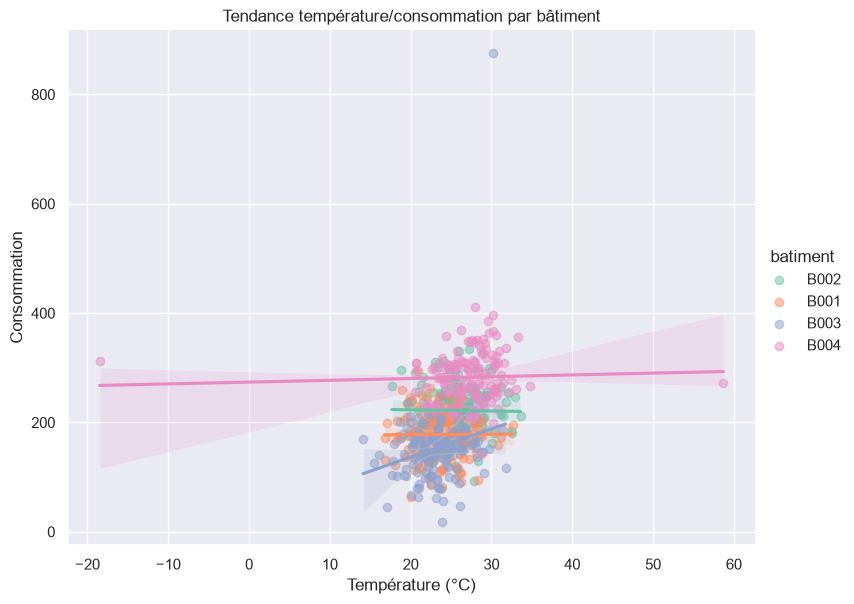

In [161]:
sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment", 
           palette="Set2", height=6, aspect=1.3, 
           scatter_kws={"alpha": 0.5}, ci=95)
plt.title("Tendance température/consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

## Interprétation - Régression par bâtiment 

B003 semble présenter une vraie pente ascendante : sa consommation augmente avec la 
température. B001 et B002 paraissent plutôt plates, sans lien marqué. B004 semble 
également plate, avec une bande large due à ses valeurs extrêmes.

→ Cela suggère que la température n'influence pas la consommation de la même façon 
selon le bâtiment - le bâtiment lui-même semble jouer un rôle au moins aussi important 
que la température.

# Partie 9 – Corrélations 
1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.  
2) Afficher la matrice de corrélation obtenue avec Pandas 
3) Afficher le heatmap de la corrélation pour identifier : 
 a) les corrélations positives ;  
 b) les corrélations négatives ;  
 c) les corrélations proches de zéro ;  
 d) les variables qui semblent fortement liées. 

## 1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.  


In [172]:
correlations = df[["temperature", "humidite", "pression", "consommation"]].corr()



## 2) Afficher la matrice de corrélation obtenue avec Pandas 


In [171]:
df.corr(numeric_only=True)


,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


## 3) Afficher le heatmap de la corrélation pour identifier : 


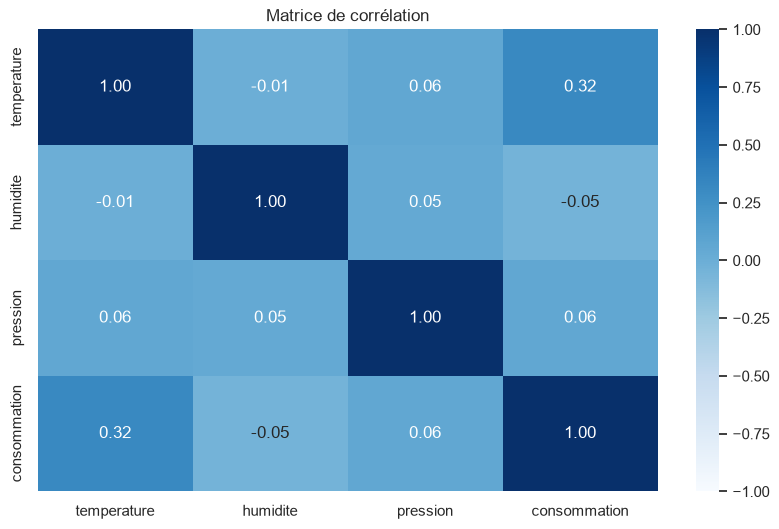

In [175]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlations, annot=True, cmap="Blues",vmin=-1, vmax=1 ,center=0, fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()



La diagonale affiche 1.00 partout - normal, chaque variable est parfaitement corrélée 
à elle-même.

a) Corrélations positives : température/consommation (0.32) ressort comme la plus 
marquée. Les autres paires positives (pression/humidité 0.05, pression/consommation 
0.06, pression/température 0.06) sont très faibles, presque nulles.

b) Corrélations négatives : température/humidité (-0.01) et humidité/consommation 
(-0.05) sont légèrement négatives, mais tellement proches de zéro qu'elles semblent 
négligeables.

c) Corrélations proches de zéro : presque toutes les paires, à l'exception de 
température/consommation - pression ne semble corrélée à rien de façon notable.

d) Variables qui semblent fortement liées : aucune paire ne dépasse 0.32 - il ne 
semble pas y avoir de lien fort entre ces variables, seulement une tendance modérée 
entre température et consommation.

→ Ça confirme que la température et la consommation sont les deux seules variables 
qui semblent avoir un vrai lien entre elles, même modéré - les autres variables 
(humidité, pression) semblent indépendantes les unes des autres et de la consommation.